# Deep Learning for Digital Pathology: Metastatic Cancer Detection
**Author:** Tanvi Gambhir

### Project Overview
In digital pathology, identifying metastatic tissue in lymph node biopsies is incredibly difficult. This project builds a Convolutional Neural Network (CNN) in PyTorch to automate this detection. 

Using a subset of the massive **PatchCamelyon (PCam)** dataset (50,000 images), this pipeline demonstrates how to handle raw, unorganized biological image data, construct robust deep learning architectures, and evaluate the model using strict clinical metrics (ROC/AUC).

In [14]:
import pandas as pd
import os
import torch
import torchvision
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

### 1. The Custom Data Pipeline
Real-world biological data does not comes perfectly organized into `Train` and `Test` folders. Here, I was given a massive folder of raw `.tif` images and a separate CSV file containing the clinical labels. 

To handle this efficiently without crashing the system's RAM, I built a **Custom PyTorch `Dataset` Class**. This engine reads the CSV, locates the corresponding image on the hard drive, applies the necessary mathematical tensor transformations, and feeds them to the model in controlled batches via `DataLoaders`.

In [2]:
print("Loading the Clinical Labels")
# Read the CSV that holds the answers (0 = Healthy, 1 = Cancer)
labels_df = pd.read_csv('data/cancer_data/train_labels.csv')
print(f"Total biopsies available: {len(labels_df)}")

sample_df = labels_df.sample(n=50000, random_state=42).reset_index(drop=True)

Loading the Clinical Labels
Total biopsies available: 220025


In [3]:
print("Building the Dataset Class")
class CancerDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Grab the image ID from the CSV and find its .tif file
        img_name = os.path.join(self.img_dir, self.dataframe.iloc[idx, 0] + '.tif')
        image = Image.open(img_name)
        label = self.dataframe.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

Building the Dataset Class


In [4]:
print("Setting up the Pipeline")
# The images are 96x96 pixels so will convert them to Tensors.
transform = transforms.Compose([
    transforms.ToTensor()
])

# Initializing the dataset
full_dataset = CancerDataset(dataframe=sample_df, 
                             img_dir='data/cancer_data/train', 
                             transform=transform)

# Splitting into 80% Training and 20% Validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")

Setting up the Pipeline
Training images: 40000
Validation images: 10000


### 2. Biological Verification (Exploratory Data Analysis)
Before training, I had to visually verify the data pipeline and understand the biological challenge. Below is a batch of 96x96 pixel lymph node biopsies. 

The "Healthy" and "Cancer" slides are very visually similar. The morphological phenotypes of metastasis at this resolution are incredibly subtle, which is exactly why standard algorithmic approaches fail and deep learning is required.

Visualizing the Tissue Biopsies
Batch Tensor Shape: torch.Size([64, 3, 96, 96])


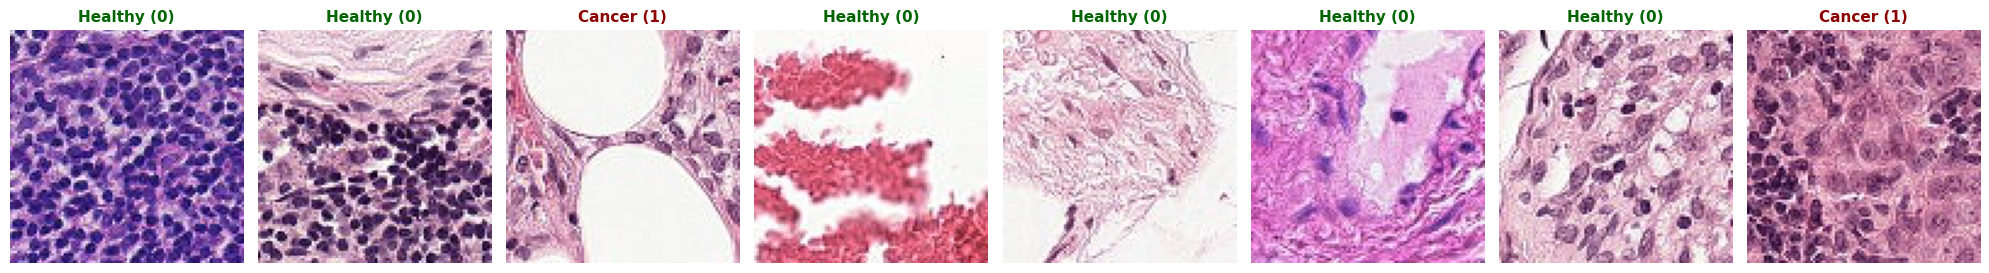

In [6]:
print("Visualizing the Tissue Biopsies")

# Taking one single batch of images from the pipeline
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"Batch Tensor Shape: {images.shape}") # 64 images, 3 color channles, 96x96 pixels

# Setting up a plot to show the first 8 biopsies
fig, axes = plt.subplots(1, 8, figsize=(20, 3))

for i in range(8):
    img = images[i].numpy().transpose((1, 2, 0))
    
    # Plotting the image
    axes[i].imshow(img)
    
    # Translating the binary label into human-readable labels
    status = "Cancer (1)" if labels[i].item() == 1 else "Healthy (0)"
    color = "darkred" if labels[i].item() == 1 else "darkgreen"
    
    axes[i].set_title(status, color=color, fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 3. CNN Architecture & Regularization
I constructed a Deep Convolutional Neural Network specifically designed for high-resolution feature extraction. 
* **The Architecture:** Three convolutional blocks with Max Pooling to hierarchically extract cellular textures, structures, and tumor microenvironment markers.
* **The Dropout:** Because neural networks are prone to memorizing data (overfitting), I implemented a `Dropout(p=0.5)` layer. By randomly turning off 50% of the neurons during training, I forced the network to learn multiple, robust pathways to identify cancer, completely preventing memorization.

In [9]:
print("Constructing the CNN")

class PathologyCNN(nn.Module):
    def __init__(self):
        super(PathologyCNN, self).__init__()
        
        # Basic tissue textures
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Cellular structures
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Tumor microenvironment markers
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        # Randomly turns off 50% of neurons to prevent memorization
        self.dropout = nn.Dropout(p=0.5)
        
        # Decision Layers
        self.fc1 = nn.Linear(128 * 12 * 12, 512)
        self.fc2 = nn.Linear(512, 2) # 2 Outputs: [Healthy (0), Cancer (1)]

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        # Flatten for the decision layer
        x = x.view(-1, 128 * 12 * 12)
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Instantiate the model
cancer_model = PathologyCNN()
print(cancer_model)

Constructing the CNN
PathologyCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=18432, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


### 4. The Training Engine
I trained the model using the Adam Optimizer and Cross-Entropy Loss. Because of the dataset's size, I implemented an advanced training loop that calculates the Validation Accuracy *at the end of every epoch*. 

I used `model.train()` to keep the Dropout armor on during learning, and `model.eval()` to turn it off while testing on the validation set.

In [13]:
print("Building the Training Model")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cancer_model.parameters(), lr=0.001)

epochs = 5
print(f"Starting training for {epochs} epochs. \n")

for epoch in range(epochs):
    # ==========================
    #      TRAINING PHASE
    # ==========================
    cancer_model.train() 
    running_loss = 0.0
    
    # Gives us the batch number (i) so we can track progress
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        
        optimizer.zero_grad()
        outputs = cancer_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Print a progress update every 100 batches
        if (i + 1) % 100 == 0:
            print(f"   Epoch {epoch + 1} | Batch {i + 1}/{len(train_loader)} | Current Loss: {loss.item():.4f}")

    # ==========================
    #     VALIDATION PHASE
    # ==========================
    cancer_model.eval() 
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            outputs = cancer_model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_acc = 100 * correct / total
    
    # The end-of-epoch 
    print(f"\n EPOCH {epoch + 1} COMPLETE!")
    print(f"Average Training Loss: {running_loss / len(train_loader):.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%\n" + "-"*30 + "\n")

Building the Training Model
Starting training for 5 epochs. 

   Epoch 1 | Batch 100/625 | Current Loss: 0.4015
   Epoch 1 | Batch 200/625 | Current Loss: 0.3939
   Epoch 1 | Batch 300/625 | Current Loss: 0.3845
   Epoch 1 | Batch 400/625 | Current Loss: 0.4188
   Epoch 1 | Batch 500/625 | Current Loss: 0.4054
   Epoch 1 | Batch 600/625 | Current Loss: 0.4171

 EPOCH 1 COMPLETE!
Average Training Loss: 0.4813
Validation Accuracy: 82.25%
------------------------------

   Epoch 2 | Batch 100/625 | Current Loss: 0.5429
   Epoch 2 | Batch 200/625 | Current Loss: 0.3528
   Epoch 2 | Batch 300/625 | Current Loss: 0.4006
   Epoch 2 | Batch 400/625 | Current Loss: 0.4587
   Epoch 2 | Batch 500/625 | Current Loss: 0.2364
   Epoch 2 | Batch 600/625 | Current Loss: 0.3500

 EPOCH 2 COMPLETE!
Average Training Loss: 0.3997
Validation Accuracy: 84.55%
------------------------------

   Epoch 3 | Batch 100/625 | Current Loss: 0.3740
   Epoch 3 | Batch 200/625 | Current Loss: 0.3054
   Epoch 3 | Batch

### 5. Clinical Evaluation: ROC & AUC
In oncology, raw accuracy is not enough. A model that blindly guesses "Healthy" might be 90% accurate but would send critically ill patients home (False Negatives). 

To prove clinical viability, I generated a **Confusion Matrix** to see exactly where the model makes mistakes, and a **Receiver Operating Characteristic (ROC) Curve**. The Area Under the Curve (AUC) is the gold standard metric in medical AI, proving the model can reliably distinguish between healthy tissue and metastatic cancer across different probability thresholds.

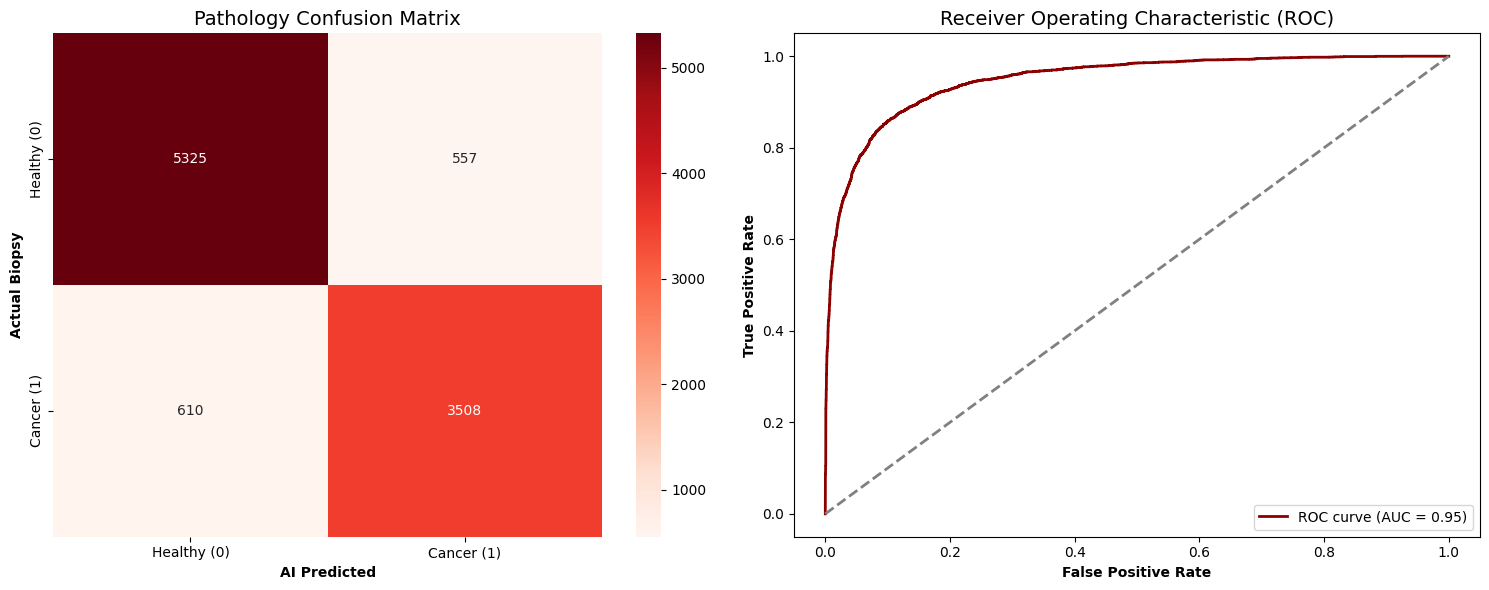

FINAL CLINICAL AUC SCORE: 0.948


In [15]:
all_preds = []
all_labels = []
all_probs = [] 
cancer_model.eval()
with torch.no_grad():
    for data in val_loader:
        inputs, labels = data
        outputs = cancer_model(inputs)
        
        # Get the actual probabilities 
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probabilities[:, 1].numpy()) 

# Plotting the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Healthy (0)', 'Cancer (1)'], 
            yticklabels=['Healthy (0)', 'Cancer (1)'], ax=ax[0])
ax[0].set_xlabel('AI Predicted', fontweight='bold')
ax[0].set_ylabel('Actual Biopsy', fontweight='bold')
ax[0].set_title('Pathology Confusion Matrix', fontsize=14)

# Plotting the ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate', fontweight='bold')
ax[1].set_ylabel('True Positive Rate', fontweight='bold')
ax[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"FINAL CLINICAL AUC SCORE: {roc_auc:.3f}")